# Detuned Sideband Synchronization


This notebook rewrites `examples/detuned_sideband_sync_demo.py` as a tutorial on branch synchronization. We intentionally drive a `gf` sideband in a dispersive model where the `n=0` and `n=1` branches do not stay perfectly synchronized under a naive resonant pulse.

The physical question is practical: if two branches see slightly different sideband frequencies, can a small drive detuning and a longer pulse improve the transfer fidelity of a superposition? The answer is yes, and the notebook shows that tradeoff explicitly.


## Imports


In [1]:

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from tutorials.workflow_tutorial_support import configure_notebook_style

configure_notebook_style()

from cqed_sim import (
    DispersiveTransmonCavityModel,
    FrameSpec,
    Pulse,
    SequenceCompiler,
    SidebandDriveSpec,
    SimulationConfig,
    carrier_for_transition_frequency,
    simulate_sequence,
)
from cqed_sim.pulses import square_envelope
from tutorials.tutorial_support import MHz

## Physics / model definition


In [2]:
scale = MHz(10.0)
g_sb = 0.35 * scale
chi = -0.2 * scale

model = DispersiveTransmonCavityModel(
    omega_c=0.0,
    omega_q=0.0,
    alpha=0.0,
    chi=chi,
    kerr=0.0,
    n_cav=5,
    n_tr=3,
)
frame = FrameSpec()
target_spec = SidebandDriveSpec(mode="storage", lower_level=0, upper_level=2)

initial_state = (model.basis_state(2, 0) + model.basis_state(2, 1)).unit()
target_state = (model.basis_state(0, 1) + model.basis_state(2, 1)).unit()

base_frequency = model.sideband_transition_frequency(
    cavity_level=0,
    lower_level=0,
    upper_level=2,
    sideband="red",
    frame=frame,
)
naive_duration_s = np.pi / (2.0 * g_sb)
optimized_detuning_rad_s = 0.16 * scale
optimized_duration_s = 5.11 / scale
dt_s = 0.02 / scale


## Pulse / sequence construction


In [3]:
def run_sideband_gate(*, detuning_rad_s: float, duration_s: float) -> tuple[qt.Qobj, float]:
    pulse = Pulse(
        "sb",
        0.0,
        duration_s,
        square_envelope,
        amp=g_sb,
        carrier=carrier_for_transition_frequency(base_frequency + detuning_rad_s),
    )
    compiled = SequenceCompiler(dt=dt_s).compile([pulse], t_end=duration_s)
    result = simulate_sequence(
        model,
        compiled,
        initial_state,
        {"sb": target_spec},
        config=SimulationConfig(frame=frame),
    )
    fidelity = abs(target_state.overlap(result.final_state)) ** 2
    return result.final_state, float(fidelity)


## Simulation


In [4]:
naive_state, naive_fidelity = run_sideband_gate(detuning_rad_s=0.0, duration_s=naive_duration_s)
optimized_state, optimized_fidelity = run_sideband_gate(
    detuning_rad_s=optimized_detuning_rad_s,
    duration_s=optimized_duration_s,
)

detuning_scan_mhz = np.linspace(-4.0, 4.0, 31)
detuning_scan_fidelity = np.asarray(
    [
        run_sideband_gate(detuning_rad_s=MHz(detuning_mhz), duration_s=optimized_duration_s)[1]
        for detuning_mhz in detuning_scan_mhz
    ],
    dtype=float,
)

print("Naive fidelity:", naive_fidelity)
print("Optimized fidelity:", optimized_fidelity)


Naive fidelity: 0.7284211453044214
Optimized fidelity: 0.9201540942477614


## Analysis / visualization


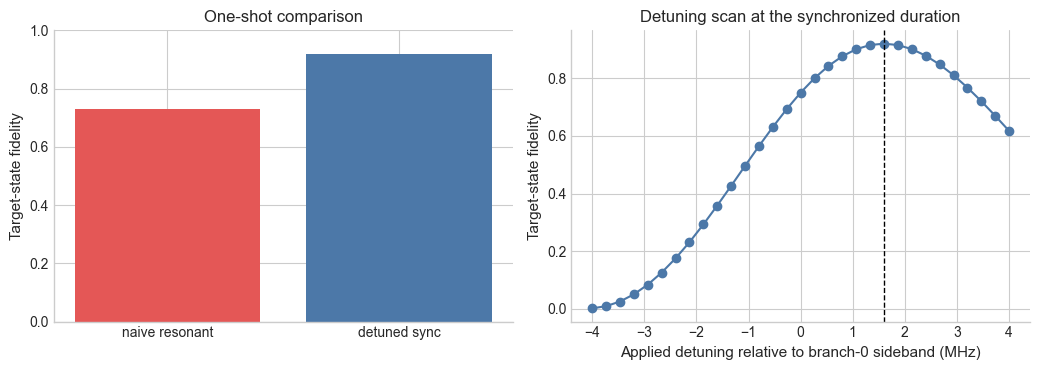

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

axes[0].bar(
    ["naive resonant", "detuned sync"],
    [naive_fidelity, optimized_fidelity],
    color=["#E45756", "#4C78A8"],
)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_ylabel("Target-state fidelity")
axes[0].set_title("One-shot comparison")

axes[1].plot(detuning_scan_mhz, detuning_scan_fidelity, "o-", color="#4C78A8")
axes[1].axvline(optimized_detuning_rad_s / MHz(1.0), color="black", ls="--", lw=1.0)
axes[1].set_xlabel("Applied detuning relative to branch-0 sideband (MHz)")
axes[1].set_ylabel("Target-state fidelity")
axes[1].set_title("Detuning scan at the synchronized duration")

plt.tight_layout()
plt.show()


## Interpretation


The dispersive shift makes different Fock branches accumulate phase at slightly different rates, so a simple resonant pulse is not always the best compromise for a superposition. A modest drive detuning plus a longer pulse can improve the overlap with the desired synchronized target.

This example stays within the current effective sideband abstraction. It is not a microscopic coupler model, and the notebook is honest about that abstraction level.


## Variations / exercises


- Sweep the pulse duration together with the detuning to reproduce the optimization surface more fully.
- Start from a different superposition and see whether the same detuning remains optimal.
- Compare this branch-synchronization idea with the simpler single-branch sideband swap in the previous notebook.
